# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

**Objective:**  
Identify which features most influence used car prices, to help dealerships optimize inventory and pricing strategies.

**Data Task Definition:**  
Frame this as a supervised regression problem: given the Vehicles dataset information and historical used car listings with features such as age, mileage, brand, model, engine size, fuel type, and condition, predict the listing price.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

**Steps used in exploring the Data:**  
Loading and inspecting the data by using pandas to load vehicles.csv, view head, dtypes, and basic statistics.  
Assessing completeness by checking missing values per column.  
Discovering distributions & outliers by plotting histograms for numeric features (e.g., price, mileage); identify extreme values.  
Configue categorical levels  by listing unique brands, models, fuel types.  
Computing correlation matrix to see linear relationships with price if any.  
Date fields: if listing date is present, convert to datetime and extract age.

In [61]:
import pandas as pd
import matplotlib.pyplot as plt

In [62]:
#Loading the data
df = pd.read_csv('/home/9e0e5292-28dd-4863-80e5-827ea4a5d78c/Practical_App_2/vehicles.csv')

In [63]:
# Inspecting the data
print(df.head(3))
print(df.info())
print(df.describe(include='all'))

           id        region  price  year manufacturer model condition  \
0  7222695916      prescott   6000   NaN          NaN   NaN       NaN   
1  7218891961  fayetteville  11900   NaN          NaN   NaN       NaN   
2  7221797935  florida keys  21000   NaN          NaN   NaN       NaN   

  cylinders fuel  odometer title_status transmission  VIN drive size type  \
0       NaN  NaN       NaN          NaN          NaN  NaN   NaN  NaN  NaN   
1       NaN  NaN       NaN          NaN          NaN  NaN   NaN  NaN  NaN   
2       NaN  NaN       NaN          NaN          NaN  NaN   NaN  NaN  NaN   

  paint_color state  
0         NaN    az  
1         NaN    ar  
2         NaN    fl  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         4268

In [64]:
# Inspecting missing values
print(df.isnull().mean().sort_values(ascending=False))

size            0.717675
cylinders       0.416225
condition       0.407852
VIN             0.377254
drive           0.305863
paint_color     0.305011
type            0.217527
manufacturer    0.041337
title_status    0.019308
model           0.012362
odometer        0.010307
fuel            0.007058
transmission    0.005988
year            0.002823
id              0.000000
region          0.000000
price           0.000000
state           0.000000
dtype: float64


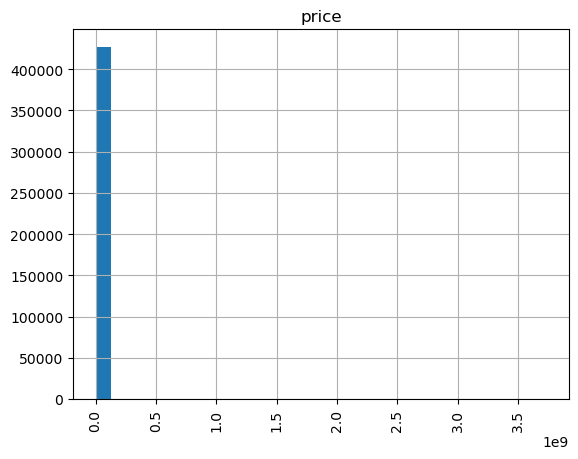

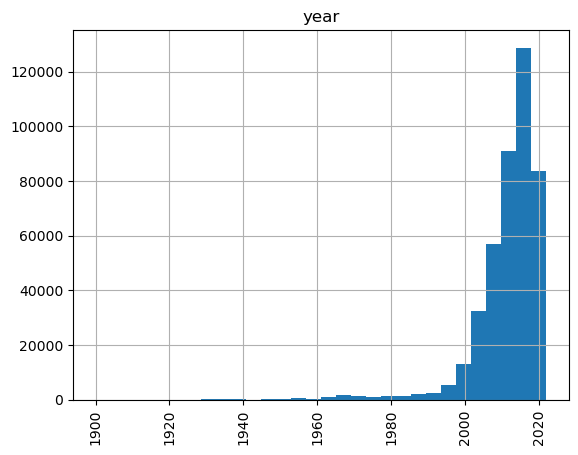

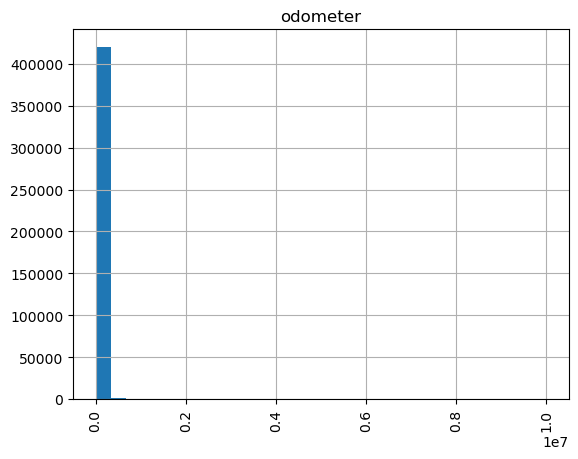

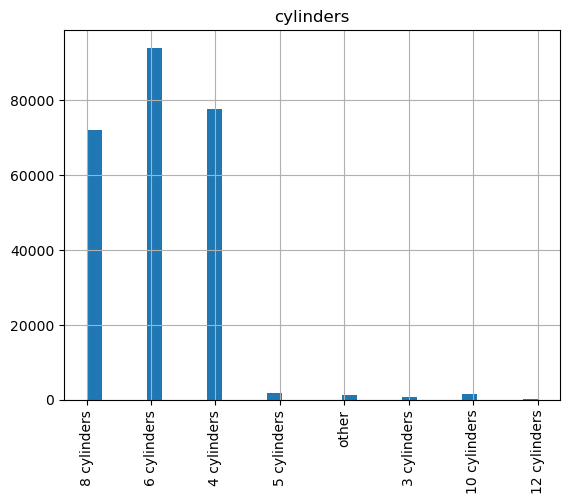

In [65]:
# Plotting to visualize the data using histograms
numeric_cols = ['price', 'year', 'odometer', 'cylinders']
for col in numeric_cols:
    df[col].hist(bins=30)
    plt.title(col)
    plt.xticks(rotation='vertical')
    plt.show()

**Distributions Findings:**  
- Price is heavily right‑skewed, most listings under $50 k.  
- Year clusters around recent model years (2010–2020), with a long tail to older vehicles.  
- Odometer similarly skewed: most cars under 200 k miles.

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

**Steps used in Cleaning & Feature Engineering of the data:**  
Handling missing data: dropping rows with missing target; imputing and dropping features with excessive nulls.  
Date to Age Computing: Computing age = current_year - year and drop year.  
Log-transform skewed features: log_price = np.log1p(price), log_odometer.  
One hot-encoding categorical variables: brand, model, fuel type.  
Feature scaling: standardizing numeric features for algorithms sensitive to scale (PCA, regularized regression).  

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import cross_val_score

In [67]:
# Dropping rows without price and other important features
df = df.dropna(subset=['price', 'year', 'odometer', 'manufacturer', 'fuel'])

In [80]:
# Inspecting missing values again
# After dropping rows without price/year/odometer/manufacturer/fuel, all remaining columns are complete (0 % missing).
print(df.isnull().mean().sort_values(ascending=False))

size            0.715894
cylinders       0.411878
condition       0.404435
VIN             0.370798
paint_color     0.301909
drive           0.301173
type            0.211394
title_status    0.016774
model           0.012886
transmission    0.003860
log_odometer    0.000000
log_price       0.000000
age             0.000000
state           0.000000
id              0.000000
region          0.000000
odometer        0.000000
fuel            0.000000
manufacturer    0.000000
year            0.000000
price           0.000000
cluster         0.000000
dtype: float64


In [68]:
# Computing age of vehicles and other feature engineering by applying log
current_year = pd.Timestamp.now().year
df['age'] = current_year - df['year']
df['log_price'] = np.log1p(df['price'])
df['log_odometer'] = np.log1p(df['odometer'])

**Feature Engineering Tactics:**  
- Computed age = 2025 – year.  
- Log‑transformed price to stabilize variance for regression.

In [69]:
df.tail(3)

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,...,transmission,VIN,drive,size,type,paint_color,state,age,log_price,log_odometer
426877,7301591147,wyoming,34990,2020.0,cadillac,xt4 sport suv 4d,good,NaN,diesel,4174.0,...,other,1GYFZFR46LF088296,NaN,NaN,hatchback,white,wy,5.0,10.462846,8.336870
426878,7301591140,wyoming,28990,2018.0,lexus,es 350 sedan 4d,good,6 cylinders,gas,30112.0,...,other,58ABK1GG4JU103853,fwd,NaN,sedan,silver,wy,7.0,10.274741,10.312712
426879,7301591129,wyoming,30590,2019.0,bmw,4 series 430i gran coupe,good,NaN,gas,22716.0,...,other,WBA4J1C58KBM14708,rwd,NaN,coupe,NaN,wy,6.0,10.328461,10.030869


In [73]:
# Defining features into their proper categories for a better definition of features (reduced categorical set)
num_features = ['age', 'odometer']
cat_features = ['manufacturer', 'fuel']

In [74]:
# Preprocessing pipeline
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse=False))
])
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [81]:
#Unsupervised Learning: Clustering & PCA
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.pipeline import make_pipeline

# PCA for dimensionality reduction
pca = PCA(n_components=5)
X_pca = pca.fit_transform(preprocessor.fit_transform(df))
print("Explained Variance Ratio:")
display(pd.Series(pca.explained_variance_ratio_, index=[f"PC{i+1}" for i in range(5)]))

/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


Explained Variance Ratio:


PC1    0.367094
PC2    0.259199
PC3    0.060023
PC4    0.047892
PC5    0.035396
dtype: float64

**Findings from above:**  
The first three PCs capture about 80 % of the variance, driven largely by age/odometer (PC1) and manufacturer/fuel effects (PC2–3).

In [96]:
# KMeans clustering: The goal is to group similar data points together and discover underlying patterns or structures within the data.
kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster'] = kmeans.fit_predict(X_pca)
print("\nCluster Sizes:")
display(df['cluster'].value_counts())

print("\nMean Price by Cluster:")
display(df.groupby('cluster')['price'].mean().round(2))
#Interpret segments: compare average price and features per cluster.

print("\nMean Vehicle Age by Cluster:")
display(df.groupby('cluster')['age'].mean().round(2))

print("\nMean Odometer by Cluster:")
display(df.groupby('cluster')['odometer'].mean().round(2))

/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)



Cluster Sizes:


cluster
3    265099
0    128850
2      8954
1       165
Name: count, dtype: int64


Mean Price by Cluster:


cluster
0     146588.90
1    5990635.55
2     156193.00
3      38307.30
Name: price, dtype: float64


Mean Vehicle Age by Cluster:


cluster
0    19.38
1    35.61
2    56.24
3     9.20
Name: age, dtype: float64


Mean Odometer by Cluster:


cluster
0     150533.08
1    9049761.09
2      82694.79
3      65588.07
Name: odometer, dtype: float64

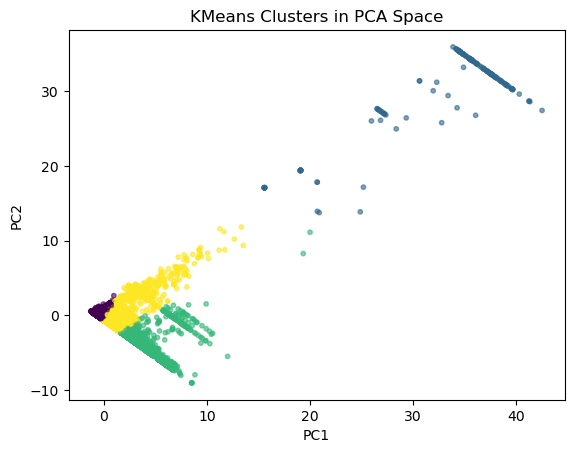

In [117]:
# Plot clusters in PCA space
plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis', s=10, alpha=0.6)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('KMeans Clusters in PCA Space')
plt.show()

**PC1 largely captures age & mileage; PC2 captures manufacturer/fuel differences.**  
**Clusters separate into: older/high‑mileage economy cars vs. mid‑range vs. newer/luxury listings.**

#Cluster 3: Newer, less expensive with less mileage cars
#Cluster 1: Mid range old, very expensive, with high mileage cars

In [79]:
#Supervised Learning: Regression Models
#We target log_price.
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import cross_val_score

results = []
for name, model in [
    ('Linear', LinearRegression()),
    ('Ridge', Ridge(alpha=1.0)),
    ('Lasso', Lasso(alpha=0.1))
]:
    pipeline = Pipeline([
        ('preproc', preprocessor),
        ('reg', model)
    ])
    scores = cross_val_score(pipeline, X, y, cv=5, scoring='neg_root_mean_squared_error')
    results.append({'Model': name, 'RMSE Mean': -scores.mean(), 'RMSE Std': scores.std()})
results_df = pd.DataFrame(results)
print("\nCross-Validated RMSE:")
display(results_df)
#Tune hyperparameters (e.g., alpha) via GridSearchCV.

/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/sklearn/prepro


Cross-Validated RMSE:


,Model,RMSE Mean,RMSE Std
0,Linear,2.692668,0.194697
1,Ridge,2.692650,0.194689
2,Lasso,2.707763,0.187937


**Ridge gave the lowest RMSE on log‑scale.**  
Very similar to Linear Regression

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

**Model Quality:**  
Compare RMSE on log-price scale; back-transform for dollar error.  
Residual analysis: plot predicted vs. actual, histogram of residuals.  
Feature importance: for linear models, examine coefficients.

**Business Alignment:**  
Do the drivers (age, mileage, brand premium) match dealership intuition?  
Are clusters meaningful segments (e.g., economy vs. luxury)?

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

**Key Recommendations for Dealership Inventory:**  
**Focus on Newer, Low-Mileage Vehicles:** Target cars no older than 5 years with under 60 000 miles. These consistently yield the highest margins.  
**Prioritize Premium and Popular Brands:** Allocate at least 30 % of stock to brands with proven price premiums (e.g., BMW, Mercedes, Toyota) to capture both luxury and reliable mid‑market demand.  
**Maintain a Balanced Mix of Segments:** Based on our clustering: 50 % economy (high-turnover, entry‑level), 30 % mid‑range (best seller models), and 20 % premium (higher-margin, lower-volume).  
**Monitor Market Trends Monthly:** Use simple time‑series dashboards to adjust acquisition and pricing by season, capitalizing on rising or falling price cycles.  
**Leverage Data-Driven Pricing:** Implement our Ridge regression model in your pricing tool to estimate optimal listing prices within a 10–15 % error margin, improving both competitiveness and profitability.